In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

print(customers.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB
None


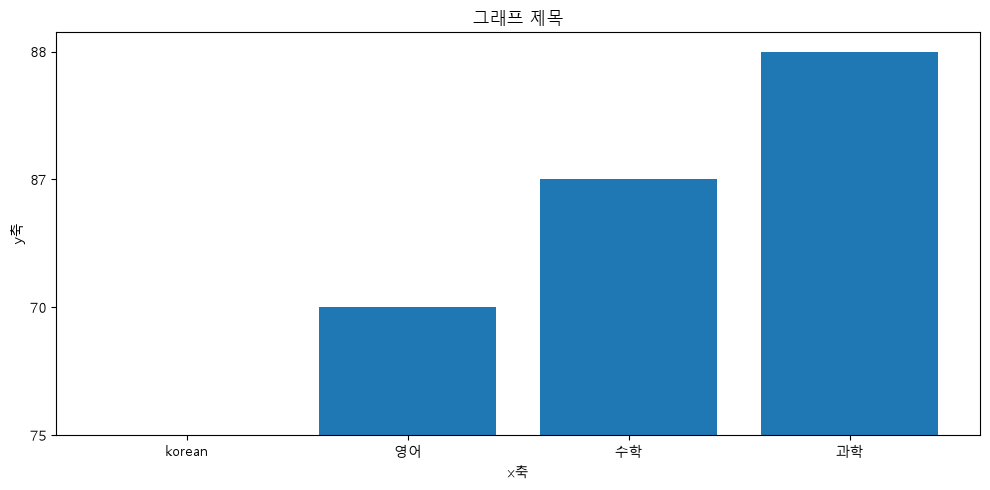

In [ ]:

import matplotlib.pyplot as plt

x_data =["국어","영어","수학","과학"]
y_data =["75","70","87","88"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()

fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
orders.head()
orders["order_date"] = pd.to_datetime(orders["order_date"], errors = "raise")
orders.info() #날짜 타입으로 바꿈. 

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.0 KB


In [ ]:
#font for루프
from matplotlib import font_manager
installed_fonts = {font.name for font in  font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic","AppleGothic","Apple SD Gothic Neo",
                    "Noto Sans CJK KR","NanumGothic"]


In [17]:
#이중 for문 (아무 컴퓨터에서 다 쓸수 있게끔 하려고.)
# import matplotlib_pyplot as plt

korean_font = korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print("선택된 한글 폰트:", korean_font)
if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트: Malgun Gothic


In [38]:
products_cleaned.to_csv("..\..\data\processed\products_clean.csv")

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\kyrdu\AppData\Local\Temp\ipykernel_14424\1806852948.py:1: SyntaxWarning: invalid escape sequence '\.'
  products_cleaned.to_csv("..\..\data\processed\products_clean.csv")


NameError: name 'products_cleaned' is not defined

In [32]:
df_visualization = pd.read_csv("../../data/processed/visualization.csv")

df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [50]:
df_visualization.info()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    752 non-null    int64  
 1   order_id         752 non-null    int64  
 2   customer_id      750 non-null    float64
 3   product_id       752 non-null    int64  
 4   order_date       741 non-null    str    
 5   order_month      741 non-null    str    
 6   order_dayofweek  741 non-null    str    
 7   payment_method   750 non-null    str    
 8   order_status     750 non-null    str    
 9   gender           746 non-null    str    
 10  age              746 non-null    float64
 11  city             746 non-null    str    
 12  signup_date      734 non-null    str    
 13  product_name     726 non-null    str    
 14  category         726 non-null    str    
 15  price            726 non-null    float64
 16  quantity         752 non-null    float64
 17  unit_price       752 non-nu

In [53]:
df_visualization = df_visualization.dropna()
df_visualization.isna().sum().sum()

np.int64(0)

In [54]:
category_sales = (
    df_visualization
    .groupby("category", as_index=False)
    .agg(
        completed_amount=("line_total", "sum")
    )
    .sort_values("completed_amount", ascending=False)
)

In [57]:
category_sales.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 9 to 7
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category          10 non-null     str    
 1   completed_amount  10 non-null     float64
dtypes: float64(1), str(1)
memory usage: 332.0 bytes


In [55]:
df_visualization.columns

Index(['order_item_id', 'order_id', 'customer_id', 'product_id', 'order_date',
       'order_month', 'order_dayofweek', 'payment_method', 'order_status',
       'gender', 'age', 'city', 'signup_date', 'product_name', 'category',
       'price', 'quantity', 'unit_price', 'line_total', 'order_match',
       'product_match', 'customer_match', 'merge_valid'],
      dtype='str')

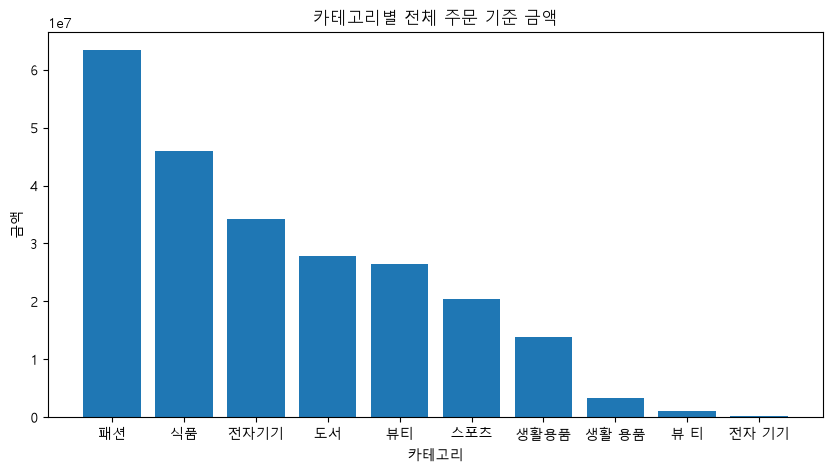

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["completed_amount"]
)

ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

plt.show()

In [58]:
df_visualization.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    700 non-null    int64  
 1   order_id         700 non-null    int64  
 2   customer_id      700 non-null    float64
 3   product_id       700 non-null    int64  
 4   order_date       700 non-null    str    
 5   order_month      700 non-null    str    
 6   order_dayofweek  700 non-null    str    
 7   payment_method   700 non-null    str    
 8   order_status     700 non-null    str    
 9   gender           700 non-null    str    
 10  age              700 non-null    float64
 11  city             700 non-null    str    
 12  signup_date      700 non-null    str    
 13  product_name     700 non-null    str    
 14  category         700 non-null    str    
 15  price            700 non-null    float64
 16  quantity         700 non-null    float64
 17  unit_price       700 non-null   

In [62]:
monthly_sales = df_visualization.groupby(df_visualization["order_month"], as_index=False).agg(
    total_amount = ("line_total","sum"),
    order_count = ("order_id","nunique")
).sort_index()

Text(0, 0.5, '금액')

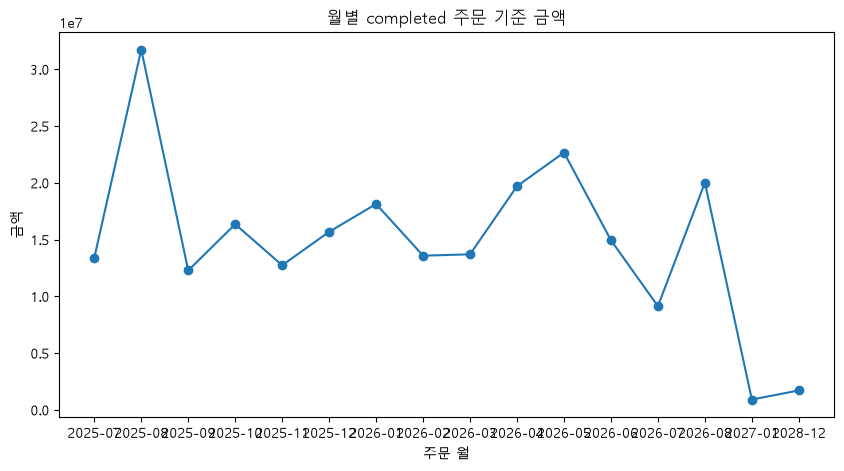

In [64]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

In [67]:
products.head()

,product_id,product_name,category,price
0,1,전자기기 상품 001,전자기기,160000
1,2,도서 상품 002,도서,34000
2,3,전자기기 상품 003,전자기기,152000
3,4,생활용품 상품 004,생활용품,70000
4,5,식품 상품 005,식품,186000


In [68]:
products["price"].describe()

count       100.000000
mean     110040.000000
std       56433.910574
min        5000.000000
25%       65750.000000
50%      112000.000000
75%      161000.000000
max      200000.000000
Name: price, dtype: float64

Text(0, 0.5, '상품 수')

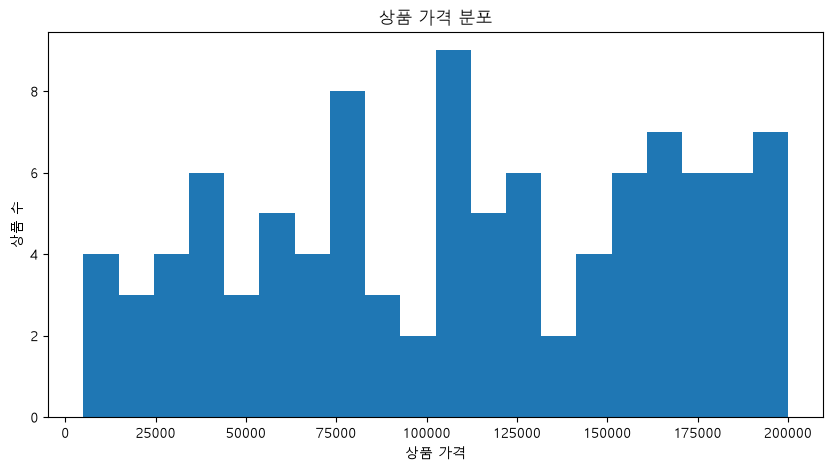

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=20,
)

ax.set_title("상품 가격 분포")
ax.set_xlabel("상품 가격")
ax.set_ylabel("상품 수")

Text(0, 0.5, '고객 수')

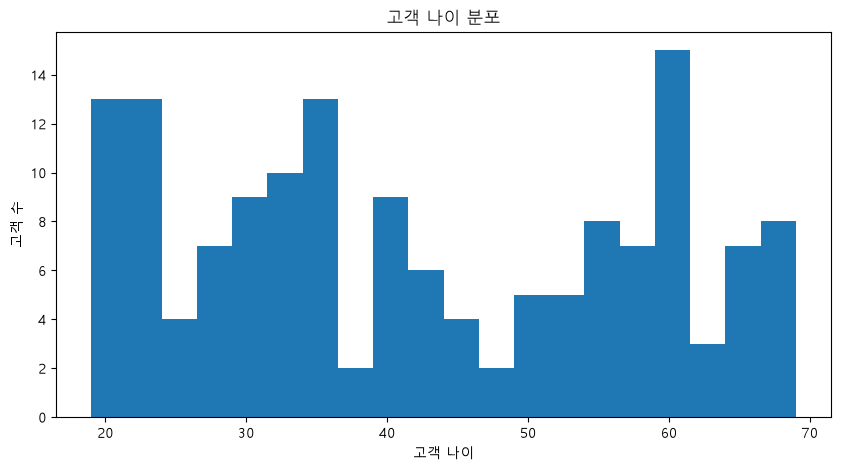

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    customers["age"],
    bins=20,
)

ax.set_title("고객 나이 분포")
ax.set_xlabel("고객 나이")
ax.set_ylabel("고객 수")

In [ ]:

product_quantity = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity = ("quantity","sum")
)
product_quantity

,product_id,total_quantity
0,1,20.0
1,2,19.0
2,3,7.0
3,4,23.0
4,5,24.0
...,...,...
91,96,75.0
92,97,31.0
93,98,25.0
94,99,18.0


In [72]:
product_sales = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity = ("quantity","sum"),
    total_amount = ("line_total","sum")
)
product_sales

,product_id,total_quantity,total_amount
0,1,20.0,1220000.0
1,2,19.0,2926000.0
2,3,7.0,336000.0
3,4,23.0,759000.0
4,5,24.0,1752000.0
...,...,...,...
91,96,75.0,7200000.0
92,97,31.0,5797000.0
93,98,25.0,800000.0
94,99,18.0,3366000.0


Text(0, 0.5, 'completed 판매 수량')

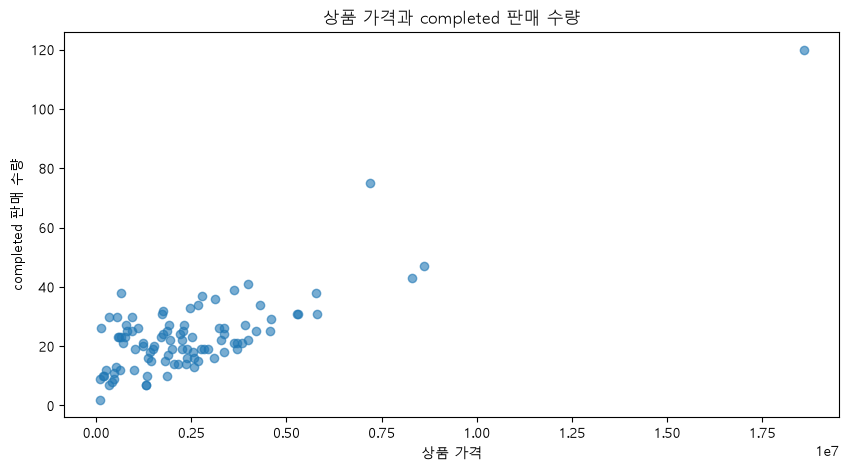

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(

    product_sales["total_amount"],
    product_sales["total_quantity"],
    alpha=0.6,

)

ax.set_title("상품 가격과 completed 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("completed 판매 수량")

In [79]:
customer_sales = df_visualization.groupby("customer_id",dropna=False, as_index=False).agg(
    total_amount = ("line_total","sum"),
    order_count = ("order_id","nunique")
).sort_values("total_amount",ascending=False)

customer_sales

,customer_id,total_amount,order_count
15,18.0,16666000.0,2
2,3.0,8909000.0,7
17,20.0,6200000.0,6
45,52.0,5388000.0,5
11,14.0,5122000.0,4
...,...,...,...
105,131.0,176000.0,1
58,72.0,160000.0,1
70,86.0,128000.0,1
103,129.0,88000.0,1


In [80]:
top_customers = customer_sales.head(10).reset_index(drop=True)
top_customers

,customer_id,total_amount,order_count
0,18.0,16666000.0,2
1,3.0,8909000.0,7
2,20.0,6200000.0,6
3,52.0,5388000.0,5
4,14.0,5122000.0,4
5,55.0,4850000.0,6
6,90.0,4847000.0,5
7,22.0,4667000.0,4
8,15.0,4281000.0,5
9,115.0,3988000.0,4


<BarContainer object of 10 artists>

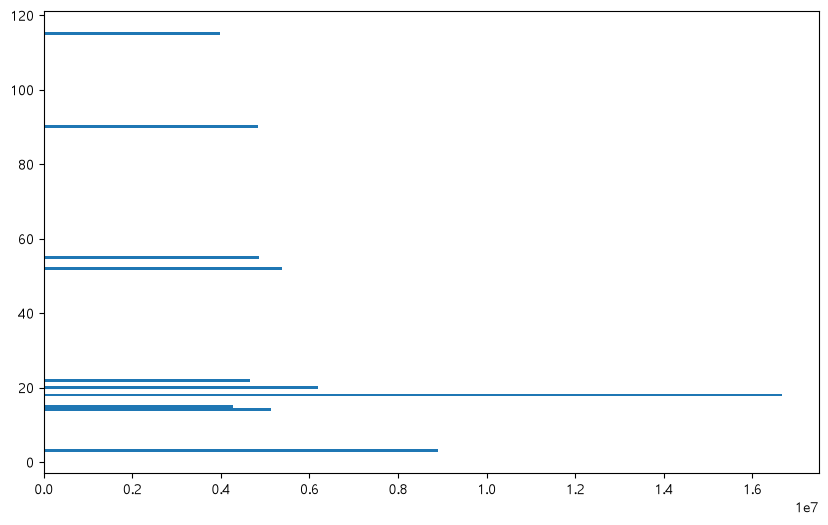

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)